<a href="https://colab.research.google.com/github/LatifahMohmmead/MISBAR/blob/main/MISBAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Misbar — Data Exploration & Cleaning
Predictive Data Quality & Anomaly Monitoring for E-Commerce Data Warehouses

Datasets used (6 of 9 — `geolocation`, `product_category_name_translation`, and `order_reviews` dropped):
`orders`, `order_items`, `order_payments`, `products`, `customers`, `sellers`

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
orders    = pd.read_csv('olist_orders_dataset.csv')
items     = pd.read_csv('olist_order_items_dataset.csv')
payments  = pd.read_csv('olist_order_payments_dataset.csv')
products  = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
sellers   = pd.read_csv('olist_sellers_dataset.csv')

Function to inspect each DataFrame for quick summary(shape, nulls, duplicates) To give us a quick exploration

In [ ]:
def explore(table, df):
    print(f'---{ table} ---')
    print('Info:', df.info())
    print('Shape:', df.shape)
    print('Nulls:\n', df.isnull().sum()[df.isnull().sum() > 0])
    print('Duplicate rows:', df.duplicated().sum())

In [ ]:
tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'products': products,
    'customers': customers, 'sellers': sellers
}
for t, df in tables.items():
    explore(t, df)

---orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Info: None
Shape: (99441, 8)
Nulls:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicate rows: 0
---items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112

Cleaning each table separately

In [ ]:
# Cleaning (items-table)
items = items.drop_duplicates()

In [ ]:
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')

In [ ]:
items['flag_bad_price']=items['price'] <= 0
items['flag_bad_freight']=items['freight_value'] < 0
items[['flag_bad_price','flag_bad_freight']].sum() #need error injuction for further steps

,0
flag_bad_price,0
flag_bad_freight,0


In [ ]:
# Cleaning (order_payments-table)
payments = payments.drop_duplicates()

In [ ]:
payments['payment_type'].value_counts() #3 not_defined

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [ ]:
payments['flag_zero_payment'] = payments['payment_value'] == 0
payments['flag_zero_payment'].sum()

np.int64(9)

In [ ]:
payments['flag_zero_payment']

,flag_zero_payment
0,False
1,False
2,False
3,False
4,False
...,...
103881,False
103882,False
103883,False
103884,False


In [ ]:
# Cleaning (products-table)
products = products.drop_duplicates()

In [ ]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [ ]:
cols_3 = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in cols_3:
    products[col] = products[col].fillna(products[col].median())

In [ ]:
info_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
products[info_cols] = products[info_cols].fillna(0)

In [ ]:
# Cleaning (customers-table)
customers = customers.drop_duplicates()

In [ ]:
# Cleaning (sellers-table)
sellers = sellers.drop_duplicates()

In [ ]:
# Making everything is clean again
tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'products': products,
    'customers': customers, 'sellers': sellers
}
for t, df in tables.items():
    explore(t, df)

---orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Info: None
Shape: (99441, 8)
Nulls:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicate rows: 0
---items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112

Merge after cleaning

In [ ]:
df = orders.merge(items, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df.shape

(118434, 36)

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_item_id,830
product_id,830
seller_id,830
shipping_limit_date,830
price,830
freight_value,830
flag_bad_price,830


In [ ]:
cols_missing = ['product_id', 'seller_id', 'payment_value']
df['flag_missing_data'] = df[cols_missing].isnull().any(axis=1)
df['flag_missing_data'].sum()

np.int64(833)

In [ ]:
df.to_csv('misbar_cleaned_dataset.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv('/content/drive/MyDrive/misbar_cleaned_dataset.csv', index=False)

# **1. Data Loading and Preparation**
This cell imports the required libraries, configures the display and visualization settings, loads the dataset, and converts the date columns to the appropriate datetime format. Converting these columns is necessary for monthly, delivery-time, and delay analyses.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="Set2")

FILE_PATH = "/content/misbar_cleaned_dataset.csv"

df = pd.read_csv(FILE_PATH, low_memory=False)

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 118,434
Columns: 37


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,flag_bad_price,flag_bad_freight,payment_sequential,payment_type,payment_installments,payment_value,flag_zero_payment,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,flag_missing_data
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,False,False,1.00,credit_card,1.00,18.12,False,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,"9,350.00",maua,SP,False
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,False,False,3.00,voucher,1.00,2.00,False,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,"9,350.00",maua,SP,False
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,False,False,2.00,voucher,1.00,18.59,False,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,"9,350.00",maua,SP,False
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,False,False,1.00,boleto,1.00,141.46,False,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,"31,570.00",belo horizonte,SP,False
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,False,False,1.00,credit_card,3.00,179.12,False,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,"14,840.00",guariba,SP,False


# **2. Data Quality Assessment**
This cell summarizes each column's data type, missing-value count, missing percentage, and number of unique values. It also checks exact duplicate rows and reports the main entity counts. Repeated order IDs are not treated as duplicates because one order may contain multiple items or payment transactions.

In [ ]:
data_quality = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean().mul(100).round(2),
    "Unique_Values": df.nunique()
}).sort_values("Missing_Percentage", ascending=False)

display(data_quality)

print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Unique orders: {df['order_id'].nunique():,}")
print(f"Unique customers: {df['customer_unique_id'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")
print(f"Unique sellers: {df['seller_id'].nunique():,}")

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
order_delivered_customer_date,datetime64[ns],3397,2.87,95664
order_delivered_carrier_date,datetime64[ns],2074,1.75,81018
order_item_id,float64,830,0.70,21
product_id,object,830,0.70,32951
shipping_limit_date,datetime64[ns],830,0.70,93318
seller_city,object,830,0.70,611
seller_state,object,830,0.70,23
seller_zip_code_prefix,float64,830,0.70,2246
product_width_cm,float64,830,0.70,95
product_height_cm,float64,830,0.70,102


Exact duplicate rows: 0
Unique orders: 99,441
Unique customers: 96,096
Unique products: 32,951
Unique sellers: 3,095


## **3. Missing Values by Order Status**
This cell examines whether missing values are associated with particular order statuses. Missing delivery dates are often expected for canceled, unavailable, shipped, or processing orders. The results are row-level counts, so they should not be interpreted as counts of unique orders.

In [ ]:
missing_by_status = (
    df.groupby("order_status")
    .agg(
        Total_Rows=("order_id", "size"),
        Missing_Approval_Date=(
            "order_approved_at",
            lambda x: x.isna().sum()
        ),
        Missing_Carrier_Date=(
            "order_delivered_carrier_date",
            lambda x: x.isna().sum()
        ),
        Missing_Delivery_Date=(
            "order_delivered_customer_date",
            lambda x: x.isna().sum()
        ),
        Missing_Product_ID=(
            "product_id",
            lambda x: x.isna().sum()
        ),
        Missing_Payment_Type=(
            "payment_type",
            lambda x: x.isna().sum()
        )
    )
    .sort_values("Total_Rows", ascending=False)
)

display(missing_by_status)

,Total_Rows,Missing_Approval_Date,Missing_Carrier_Date,Missing_Delivery_Date,Missing_Product_ID,Missing_Payment_Type
order_status,,,,,,
delivered,115038,15,2,8,0,3
shipped,1245,0,0,1245,1,0
canceled,745,156,666,738,179,0
unavailable,650,0,650,650,643,0
processing,375,0,375,375,0,0
invoiced,373,0,373,373,2,0
created,5,5,5,5,5,0
approved,3,0,3,3,0,0


# **4. Preparation of Analysis-Level Tables**
This cell separates the merged dataset into order-level, item-level, and payment-level tables. It also creates a delivered-item table for completed-sales analysis. This step prevents duplicate counting caused by the many-to-many relationship between order items and payment transactions.

In [ ]:
order_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "customer_city",
    "customer_state"
]

orders = (
    df[order_columns]
    .drop_duplicates("order_id")
    .copy()
)

items = (
    df[df["order_item_id"].notna()]
    .drop_duplicates(["order_id", "order_item_id"])
    .copy()
)

payments = (
    df[df["payment_sequential"].notna()]
    .drop_duplicates(["order_id", "payment_sequential"])
    .copy()
)

delivered_order_ids = orders.loc[
    orders["order_status"].eq("delivered"),
    "order_id"
]

sold_items = items[
    items["order_id"].isin(delivered_order_ids)
].copy()

print(f"Orders: {len(orders):,}")
print(f"Order items: {len(items):,}")
print(f"Payment transactions: {len(payments):,}")
print(f"Delivered order items: {len(sold_items):,}")

Orders: 99,441
Order items: 112,650
Payment transactions: 103,886
Delivered order items: 110,197


## 5. Main KPIs and Order Status

This cell aggregates payment transactions at the order level and combines them with the order table. It then calculates the main business indicators and visualizes the distribution of unique orders by status. Delivered payment value is used to focus on completed orders.

,Value
Total Orders,"99,441.00"
Unique Customers,"96,096.00"
Unique Products,"32,951.00"
Unique Sellers,"3,095.00"
Delivered Orders,"96,478.00"
Delivered Payment Value,"15,422,461.77"
Average Delivered Order Value,159.86


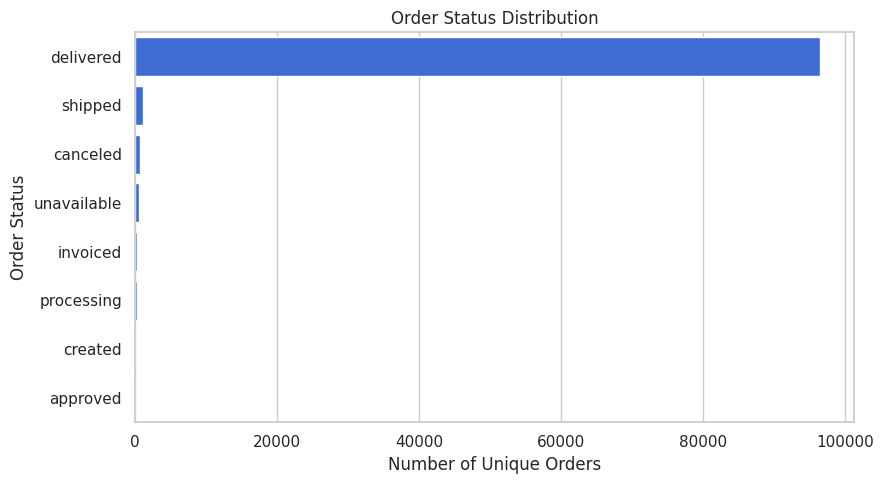

In [ ]:
order_payments = (
    payments.groupby("order_id", as_index=False)
    .agg(
        Total_Payment=("payment_value", "sum"),
        Payment_Transactions=("payment_sequential", "count"),
        Maximum_Installments=("payment_installments", "max")
    )
)

orders_analysis = orders.merge(
    order_payments,
    on="order_id",
    how="left",
    validate="one_to_one"
)

delivered_orders = orders_analysis[
    orders_analysis["order_status"].eq("delivered")
].copy()

kpis = pd.Series({
    "Total Orders": orders_analysis["order_id"].nunique(),
    "Unique Customers": orders_analysis["customer_unique_id"].nunique(),
    "Unique Products": items["product_id"].nunique(),
    "Unique Sellers": items["seller_id"].nunique(),
    "Delivered Orders": delivered_orders["order_id"].nunique(),
    "Delivered Payment Value": delivered_orders["Total_Payment"].sum(),
    "Average Delivered Order Value": delivered_orders["Total_Payment"].mean()
})

display(kpis.to_frame("Value"))

status_summary = (
    orders["order_status"]
    .value_counts()
    .rename_axis("Order_Status")
    .reset_index(name="Number_of_Orders")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=status_summary,
    x="Number_of_Orders",
    y="Order_Status",
    color="#2563EB"
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Unique Orders")
plt.ylabel("Order Status")
plt.tight_layout()
plt.show()

# **6. Monthly Performance**
This cell aggregates unique orders, customers, and payment value by purchase month. The charts help identify growth patterns, seasonality, and unusual periods. The first and last months should be interpreted carefully because they may contain incomplete periods.

,Purchase_Month,Number_of_Orders,Unique_Customers,Total_Payment
0,2016-09,4,4,252.24
1,2016-10,324,321,"59,090.48"
2,2016-12,1,1,19.62
3,2017-01,800,765,"138,488.04"
4,2017-02,1780,1755,"291,908.01"
5,2017-03,2682,2642,"449,863.60"
6,2017-04,2404,2372,"417,788.03"
7,2017-05,3700,3625,"592,918.82"
8,2017-06,3245,3180,"511,276.38"
9,2017-07,4026,3947,"592,382.92"


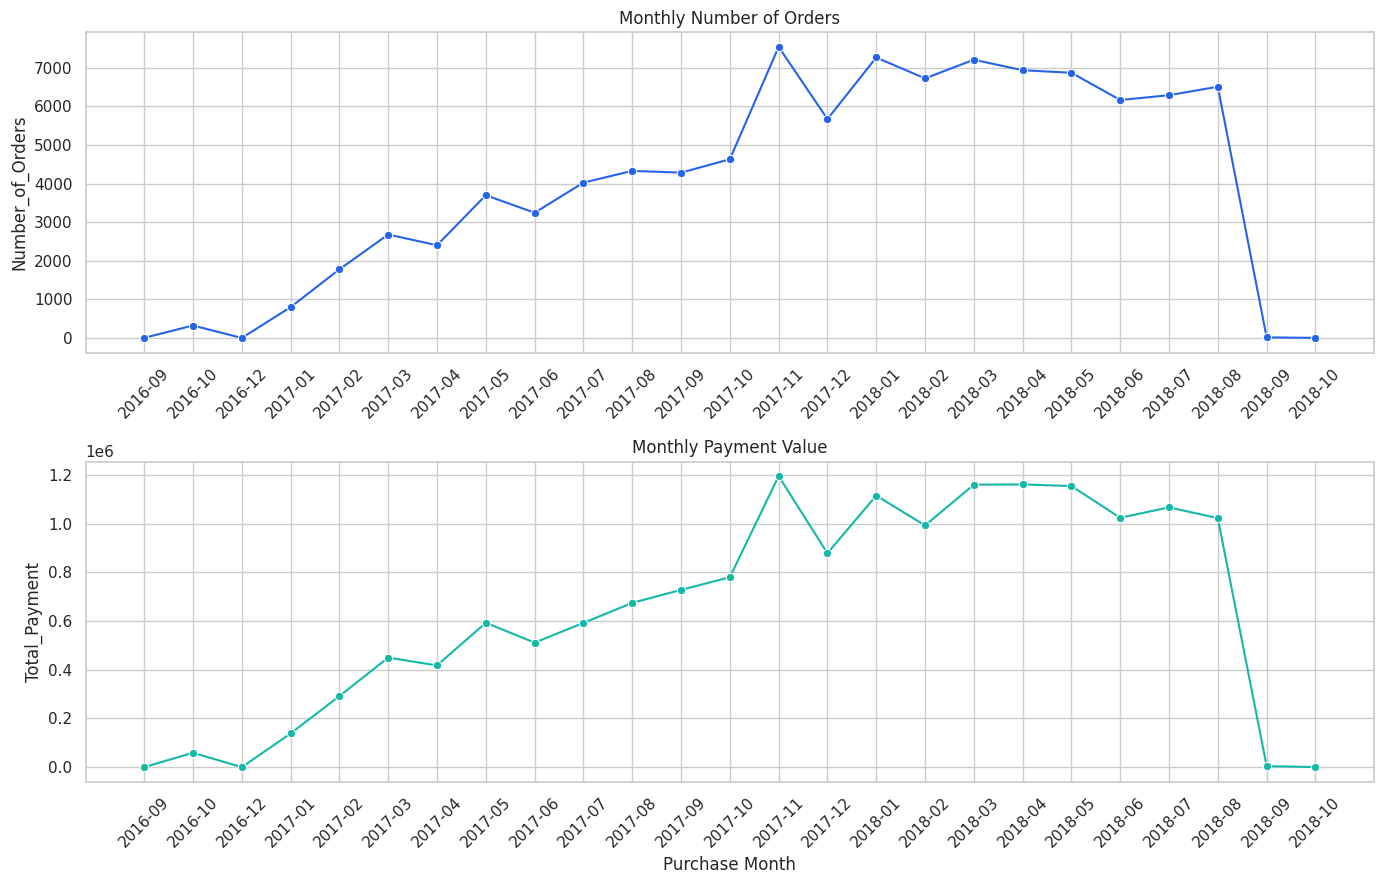

In [ ]:
orders_analysis["Purchase_Month"] = (
    orders_analysis["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    orders_analysis.groupby("Purchase_Month", as_index=False)
    .agg(
        Number_of_Orders=("order_id", "nunique"),
        Unique_Customers=("customer_unique_id", "nunique"),
        Total_Payment=("Total_Payment", "sum")
    )
    .sort_values("Purchase_Month")
)

display(monthly_summary)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.lineplot(
    data=monthly_summary,
    x="Purchase_Month",
    y="Number_of_Orders",
    marker="o",
    color="#2563EB",
    ax=axes[0]
)

axes[0].set_title("Monthly Number of Orders")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_summary,
    x="Purchase_Month",
    y="Total_Payment",
    marker="o",
    color="#14B8A6",
    ax=axes[1]
)

axes[1].set_title("Monthly Payment Value")
axes[1].set_xlabel("Purchase Month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## **7. Delivery Performance**
This cell analyzes completed orders with valid purchase, estimated-delivery, and actual-delivery dates. It calculates delivery duration and classifies orders as late or on time. The distribution chart is limited to the 99th percentile for readability without deleting extreme values from the dataset.

,Value
Average Delivery Days,12.56
Median Delivery Days,10.22
Late Orders,"7,826.00"
Late Delivery Rate (%),8.11


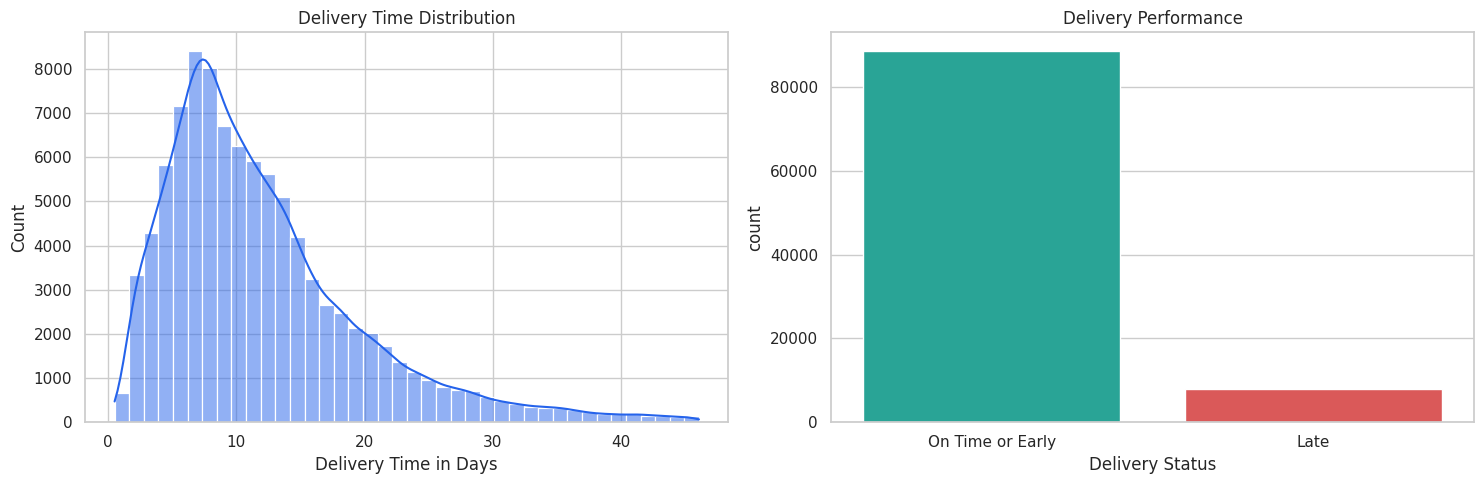

In [ ]:
delivery_analysis = delivered_orders[
    delivered_orders["order_purchase_timestamp"].notna() &
    delivered_orders["order_delivered_customer_date"].notna() &
    delivered_orders["order_estimated_delivery_date"].notna()
].copy()

delivery_analysis["Delivery_Days"] = (
    delivery_analysis["order_delivered_customer_date"] -
    delivery_analysis["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivery_analysis["Delivery_Difference_Days"] = (
    delivery_analysis["order_delivered_customer_date"] -
    delivery_analysis["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivery_analysis["Delivery_Status"] = np.where(
    delivery_analysis["Delivery_Difference_Days"] > 0,
    "Late",
    "On Time or Early"
)

delivery_kpis = pd.Series({
    "Average Delivery Days": delivery_analysis["Delivery_Days"].mean(),
    "Median Delivery Days": delivery_analysis["Delivery_Days"].median(),
    "Late Orders": delivery_analysis["Delivery_Status"].eq("Late").sum(),
    "Late Delivery Rate (%)": (
        delivery_analysis["Delivery_Status"].eq("Late").mean() * 100
    )
})

display(delivery_kpis.to_frame("Value"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

delivery_limit = delivery_analysis["Delivery_Days"].quantile(0.99)

sns.histplot(
    data=delivery_analysis[
        delivery_analysis["Delivery_Days"].between(0, delivery_limit)
    ],
    x="Delivery_Days",
    bins=40,
    kde=True,
    color="#2563EB",
    ax=axes[0]
)

axes[0].set_title("Delivery Time Distribution")
axes[0].set_xlabel("Delivery Time in Days")

sns.countplot(
    data=delivery_analysis,
    x="Delivery_Status",
    palette=["#14B8A6", "#EF4444"],
    ax=axes[1]
)

axes[1].set_title("Delivery Performance")
axes[1].set_xlabel("Delivery Status")

plt.tight_layout()
plt.show()

## 8. Payment Method Analysis

This cell summarizes the number, percentage, total value, and average value of transactions for each payment method. Payment transactions are deduplicated by order ID and payment sequence, preventing item-level duplication from inflating the results.

,payment_type,Number_of_Transactions,Total_Payment,Average_Payment,Transaction_Percentage
1,credit_card,76795,"12,542,084.19",163.32,73.92
0,boleto,19784,"2,869,361.27",145.03,19.04
4,voucher,5775,"379,436.87",65.70,5.56
2,debit_card,1529,"217,989.79",142.57,1.47
3,not_defined,3,0.00,0.00,0.00


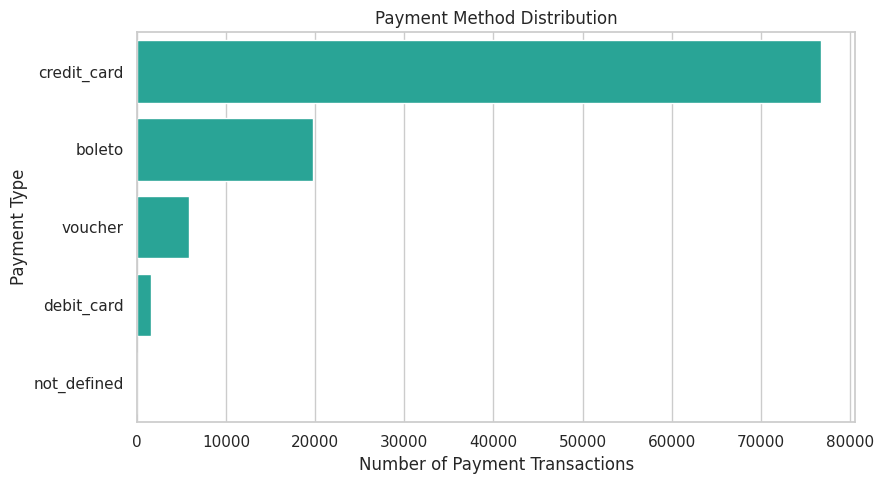

In [ ]:
payment_summary = (
    payments.groupby("payment_type", as_index=False)
    .agg(
        Number_of_Transactions=("payment_sequential", "count"),
        Total_Payment=("payment_value", "sum"),
        Average_Payment=("payment_value", "mean")
    )
    .sort_values("Number_of_Transactions", ascending=False)
)

payment_summary["Transaction_Percentage"] = (
    payment_summary["Number_of_Transactions"]
    .div(payment_summary["Number_of_Transactions"].sum())
    .mul(100)
    .round(2)
)

display(payment_summary)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_summary,
    x="Number_of_Transactions",
    y="payment_type",
    color="#14B8A6"
)

plt.title("Payment Method Distribution")
plt.xlabel("Number of Payment Transactions")
plt.ylabel("Payment Type")
plt.tight_layout()
plt.show()

## **9. Best-Selling Product Categories**
This cell identifies the leading product categories by units sold in delivered orders. It also reports the number of orders, total product value, and average price for each category. Restricting the analysis to delivered orders avoids counting canceled sales as completed sales.

,product_category_name,Units_Sold,Number_of_Orders,Total_Product_Value,Average_Price
13,cama_mesa_banho,10953,9272,"1,023,434.76",93.44
11,beleza_saude,9465,8647,"1,233,131.72",130.28
32,esporte_lazer,8431,7530,"954,852.55",113.25
54,moveis_decoracao,8160,6307,"711,927.69",87.25
44,informatica_acessorios,7644,6530,"888,724.61",116.26
73,utilidades_domesticas,6795,5743,"615,628.69",90.60
66,relogios_presentes,5859,5495,"1,166,176.98",199.04
70,telefonia,4430,4093,"309,860.23",69.95
40,ferramentas_jardim,4268,3448,"470,495.28",110.24
8,automotivo,4140,3810,"578,966.65",139.85


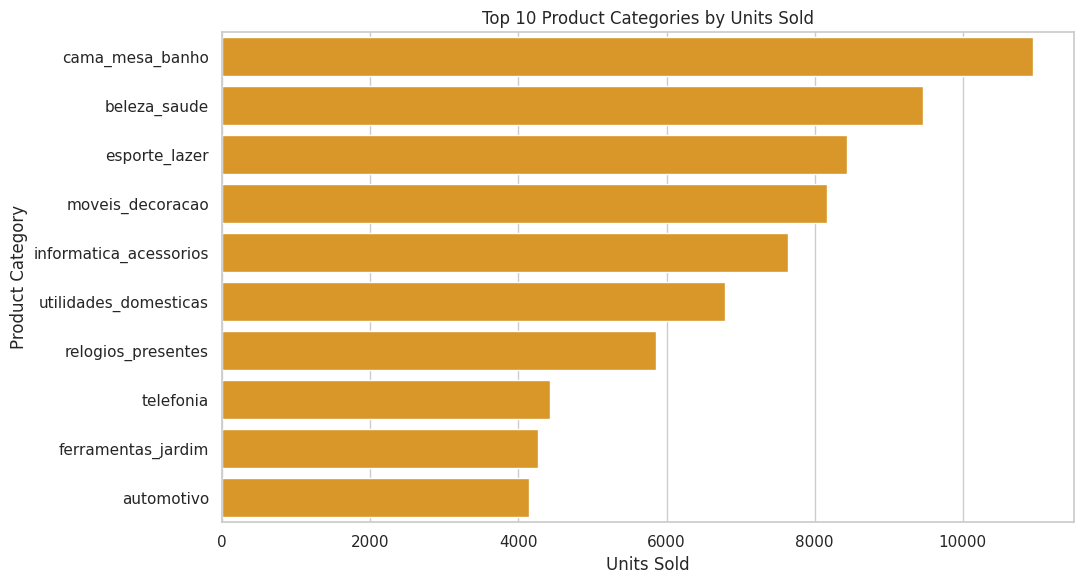

In [ ]:
category_summary = (
    sold_items.groupby("product_category_name", as_index=False)
    .agg(
        Units_Sold=("order_item_id", "count"),
        Number_of_Orders=("order_id", "nunique"),
        Total_Product_Value=("price", "sum"),
        Average_Price=("price", "mean")
    )
    .sort_values("Units_Sold", ascending=False)
)

top_categories = category_summary.head(10)

display(top_categories)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_categories,
    x="Units_Sold",
    y="product_category_name",
    color="#F59E0B"
)

plt.title("Top 10 Product Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## 10. Best-Selling Products

This cell ranks individual products by units sold in delivered orders. Because the dataset does not include readable product names, shortened product IDs are used in the chart. Total product value and average price are included to provide additional commercial context.

,product_id,product_category_name,Units_Sold,Number_of_Orders,Total_Product_Value,Average_Price,Product_Label
21617,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,520,425,"37,104.30",71.35,aca2eb7d00...
8429,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484,352,"26,577.22",54.91,422879e10f...
19290,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,477,456,"42,049.66",88.15,99a4788cb2...
7206,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,390,309,"21,336.79",54.71,389d119b48...
6926,368c6c730842d78016ad823897a372db,ferramentas_jardim,388,291,"21,056.80",54.27,368c6c7308...
10589,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,373,287,"20,387.20",54.66,53759a2ecd...
26436,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,332,313,"45,620.56",137.41,d1c427060a...
10616,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,321,304,"37,454.63",116.68,53b36df67e...
2734,154e7e31ebfa092203795c972e5804a6,beleza_saude,274,262,"6,173.26",22.53,154e7e31eb...
7881,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,272,253,"40,782.80",149.94,3dd2a17168...


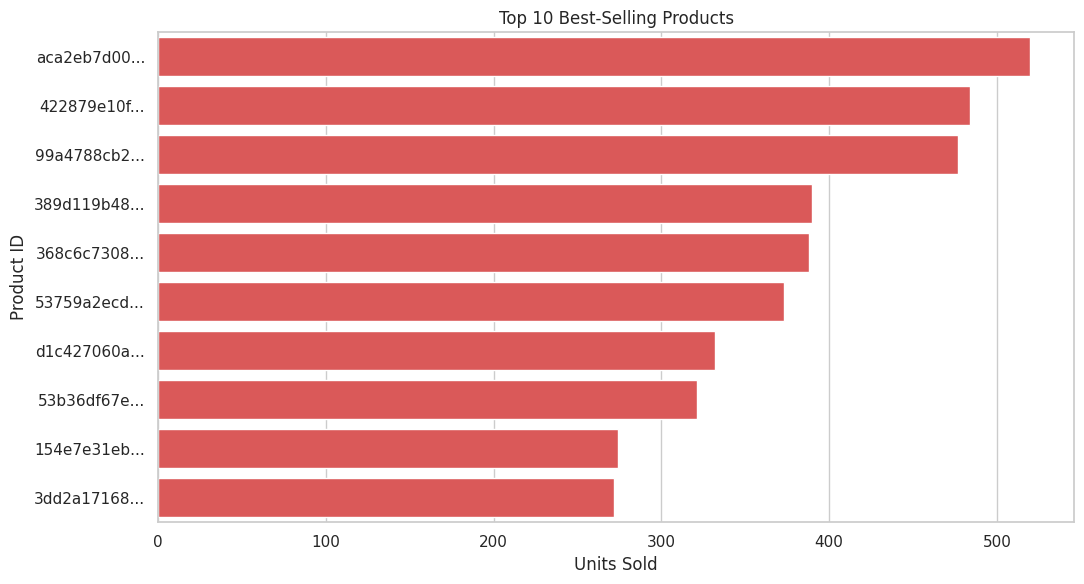

In [ ]:
product_summary = (
    sold_items.groupby(
        ["product_id", "product_category_name"],
        as_index=False,
        dropna=False
    )
    .agg(
        Units_Sold=("order_item_id", "count"),
        Number_of_Orders=("order_id", "nunique"),
        Total_Product_Value=("price", "sum"),
        Average_Price=("price", "mean")
    )
    .sort_values(
        ["Units_Sold", "Total_Product_Value"],
        ascending=[False, False]
    )
)

top_products = product_summary.head(10).copy()
top_products["Product_Label"] = (
    top_products["product_id"].str[:10] + "..."
)

display(top_products)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_products,
    x="Units_Sold",
    y="Product_Label",
    color="#EF4444"
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Units Sold")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()

## 11. Geographic Distribution of Orders

This cell identifies the states and cities with the highest numbers of unique orders. City labels include the state code to distinguish locations with similar names. The analysis also reports unique customers and total payment value for each location.

,customer_state,Number_of_Orders,Unique_Customers,Total_Payment
25,SP,41746,40302,"5,998,226.96"
18,RJ,12852,12384,"2,144,379.69"
10,MG,11635,11259,"1,872,257.26"
22,RS,5466,5277,"890,898.54"
17,PR,5045,4882,"811,156.38"
23,SC,3637,3534,"623,086.43"
4,BA,3380,3277,"616,645.82"
6,DF,2140,2075,"355,141.08"
7,ES,2033,1964,"325,967.55"
8,GO,2020,1952,"350,092.31"


,customer_city,customer_state,Number_of_Orders,Unique_Customers,Total_Payment,City_Label
3758,sao paulo,SP,15540,14984,"2,203,373.09",sao paulo (SP)
3281,rio de janeiro,RJ,6882,6620,"1,161,927.36",rio de janeiro (RJ)
469,belo horizonte,MG,2773,2672,"421,765.12",belo horizonte (MG)
587,brasilia,DF,2131,2069,"354,216.78",brasilia (DF)
1187,curitiba,PR,1521,1465,"247,392.48",curitiba (PR)
739,campinas,SP,1444,1398,"216,248.43",campinas (SP)
3080,porto alegre,RS,1379,1326,"224,731.42",porto alegre (RS)
3375,salvador,BA,1245,1209,"218,071.50",salvador (BA)
1587,guarulhos,SP,1189,1153,"165,121.99",guarulhos (SP)
3574,sao bernardo do campo,SP,938,908,"120,434.84",sao bernardo do campo (SP)


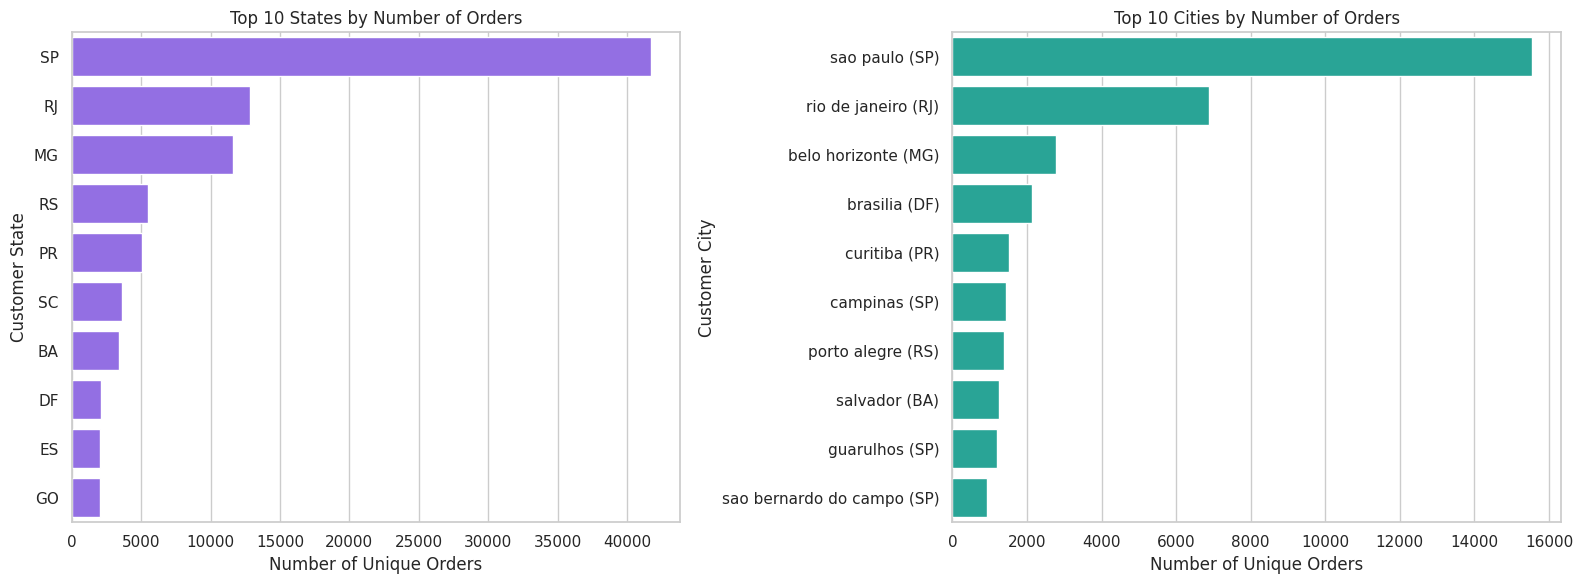

In [ ]:
state_summary = (
    orders_analysis.groupby("customer_state", as_index=False)
    .agg(
        Number_of_Orders=("order_id", "nunique"),
        Unique_Customers=("customer_unique_id", "nunique"),
        Total_Payment=("Total_Payment", "sum")
    )
    .sort_values("Number_of_Orders", ascending=False)
)

city_summary = (
    orders_analysis.groupby(
        ["customer_city", "customer_state"],
        as_index=False
    )
    .agg(
        Number_of_Orders=("order_id", "nunique"),
        Unique_Customers=("customer_unique_id", "nunique"),
        Total_Payment=("Total_Payment", "sum")
    )
    .sort_values("Number_of_Orders", ascending=False)
)

top_states = state_summary.head(10)
top_cities = city_summary.head(10).copy()

top_cities["City_Label"] = (
    top_cities["customer_city"] +
    " (" +
    top_cities["customer_state"] +
    ")"
)

display(top_states)
display(top_cities)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_states,
    x="Number_of_Orders",
    y="customer_state",
    color="#8B5CF6",
    ax=axes[0]
)

axes[0].set_title("Top 10 States by Number of Orders")
axes[0].set_xlabel("Number of Unique Orders")
axes[0].set_ylabel("Customer State")

sns.barplot(
    data=top_cities,
    x="Number_of_Orders",
    y="City_Label",
    color="#14B8A6",
    ax=axes[1]
)

axes[1].set_title("Top 10 Cities by Number of Orders")
axes[1].set_xlabel("Number of Unique Orders")
axes[1].set_ylabel("Customer City")

plt.tight_layout()
plt.show()

## 12. IQR Outlier Detection
This cell applies the interquartile range method to selected numerical product variables. Values outside 1.5 times the IQR are flagged as statistical outliers. These observations are not automatically errors and should not be removed without business or data-quality evidence

In [ ]:
def summarize_outliers(data, columns):
    results = []

    for column in columns:
        values = data[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = (
            (values < lower_bound) |
            (values > upper_bound)
        )

        results.append({
            "Column": column,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_Count": outliers.sum(),
            "Outlier_Percentage": round(outliers.mean() * 100, 2)
        })

    return pd.DataFrame(results)


outlier_columns = [
    "price",
    "freight_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

outlier_summary = summarize_outliers(
    sold_items,
    outlier_columns
)

display(outlier_summary)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,price,-101.50,275.57,8162,7.41
1,freight_value,0.98,33.25,11811,10.72
2,product_weight_g,"-1,950.00","4,050.00",15437,14.01
3,product_length_cm,-12.00,68.00,3515,3.19
4,product_height_cm,-10.00,38.00,7453,6.76
5,product_width_cm,-7.50,52.50,2486,2.26


## 13. Outlier Visualization

This cell uses box plots to display the distributions and potential outliers of prices, freight charges, product weight, and product dimensions. Points beyond the whiskers are statistically unusual, but they may still represent valid high-value, heavy, or large products.

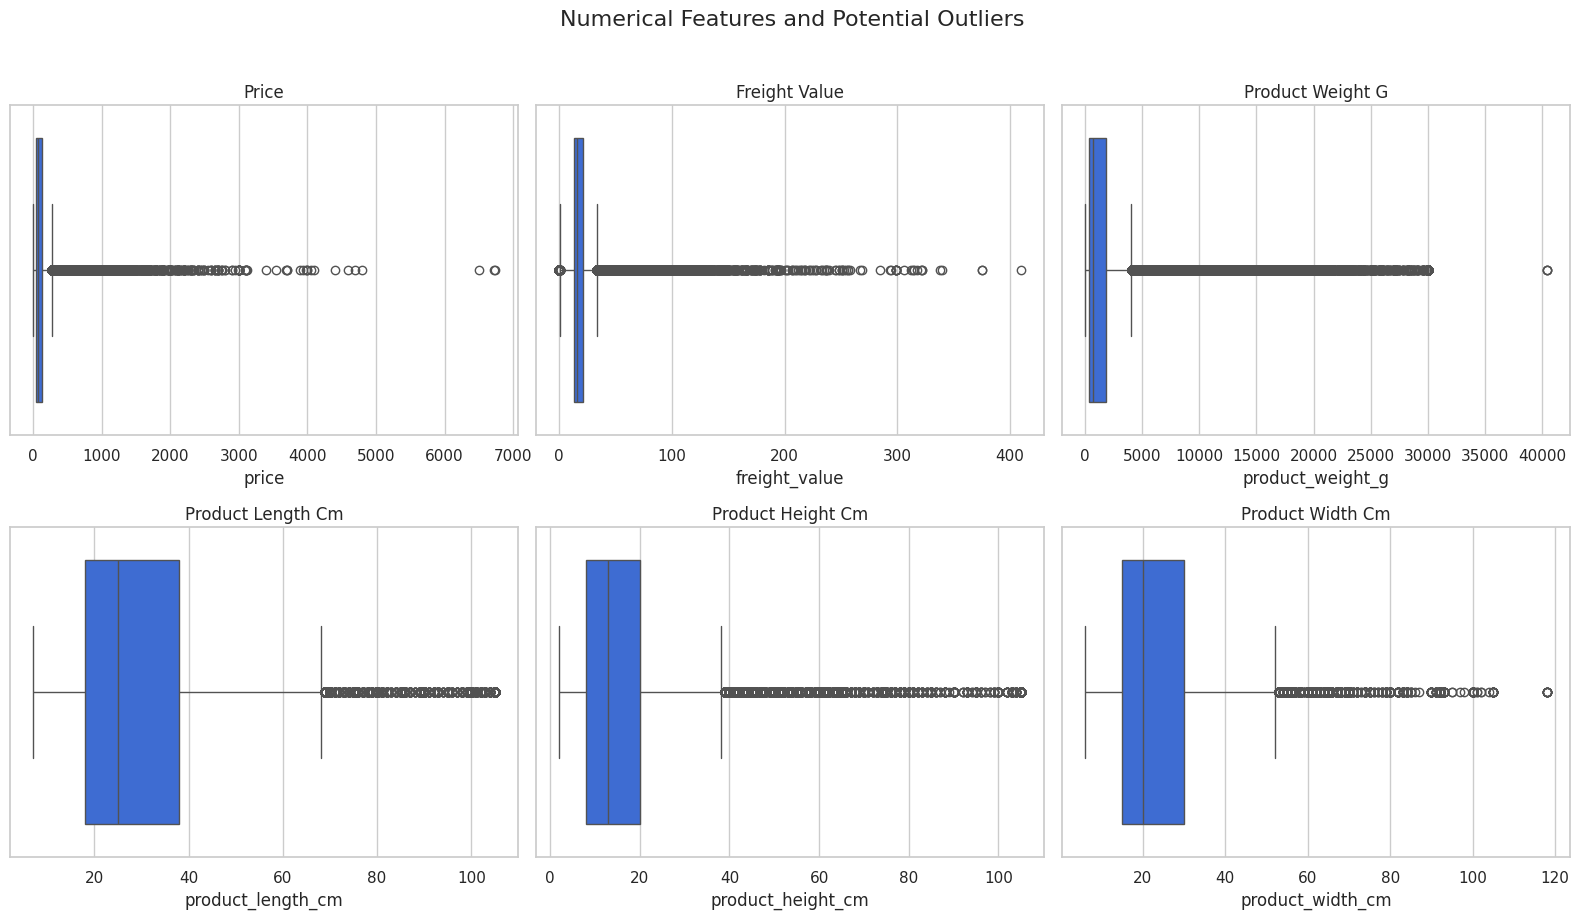

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis, column in zip(axes, outlier_columns):
    sns.boxplot(
        data=sold_items,
        x=column,
        color="#2563EB",
        ax=axis
    )

    axis.set_title(
        column.replace("_", " ").title()
    )

plt.suptitle(
    "Numerical Features and Potential Outliers",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

## 16. Order Date Consistency Checks

This cell validates the chronological sequence of key order events. It checks whether approval occurred before purchase, carrier handoff occurred before approval, or customer delivery occurred before purchase or carrier handoff. The order-level table is used so that each order is evaluated only once. Records with missing dates are excluded automatically from these comparisons.

In [ ]:
date_checks = pd.Series({
    "Approval Before Purchase": (
        orders["order_approved_at"] <
        orders["order_purchase_timestamp"]
    ).sum(),

    "Carrier Handoff Before Approval": (
        orders["order_delivered_carrier_date"] <
        orders["order_approved_at"]
    ).sum(),

    "Customer Delivery Before Purchase": (
        orders["order_delivered_customer_date"] <
        orders["order_purchase_timestamp"]
    ).sum(),

    "Customer Delivery Before Carrier Handoff": (
        orders["order_delivered_customer_date"] <
        orders["order_delivered_carrier_date"]
    ).sum()
}, name="Invalid_Order_Count")

display(date_checks.to_frame())

,Invalid_Order_Count
Approval Before Purchase,0
Carrier Handoff Before Approval,1359
Customer Delivery Before Purchase,0
Customer Delivery Before Carrier Handoff,23
